In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score
from base_utils import categoric_columns, numeric_columns


In [66]:
train_df = pd.read_csv('train_cleaned.csv')

#### 빈도 레이블 인코딩

In [67]:
# for col in categorical_features:
#     freq_encoding = train_df[col].value_counts()
#     train_df[col] = train_df[col].map(freq_encoding) 

In [68]:
# correlation_matrix = train_df.corr()

In [69]:
# target_corr = correlation_matrix['임신 성공 여부'].drop('임신 성공 여부')
# print("\n목표 변수와의 상관계수:")
# print(target_corr)

In [70]:
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

In [71]:
# 빈도 인코딩
train_encoded = X.copy()

for col in categoric_columns:
    freq_encoding = X[col].value_counts().to_dict()
    train_encoded[col] = X[col].map(freq_encoding)

### 랜덤 포레스트 특성 중요도 추출

d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\

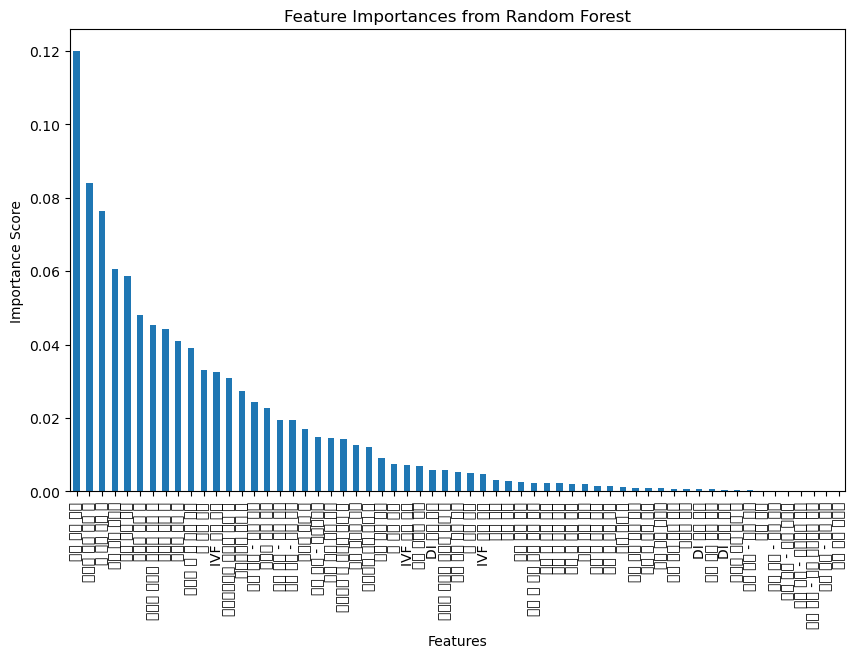

In [73]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(train_encoded, y)

# 특성 중요도 추출
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importances from Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [74]:
important_features = feature_importances[feature_importances > 0.01]
important_features

시술 시기 코드            0.119818
시술 당시 나이            0.058603
단일 배아 이식 여부         0.014531
불명확 불임 원인           0.022741
불임 원인 - 난관 질환       0.019332
불임 원인 - 남성 요인       0.024328
불임 원인 - 배란 장애       0.019552
불임 원인 - 자궁내막증       0.014787
총 시술 횟수             0.032968
클리닉 내 총 시술 횟수       0.039035
IVF 시술 횟수           0.032625
총 생성 배아 수           0.076400
미세주입된 난자 수          0.027319
미세주입에서 생성된 배아 수     0.030774
이식된 배아 수            0.044268
미세주입 배아 이식 수        0.012003
저장된 배아 수            0.040946
미세주입 후 저장된 배아 수     0.014400
해동된 배아 수            0.016963
수집된 신선 난자 수         0.083918
혼합된 난자 수            0.047974
파트너 정자와 혼합된 난자 수    0.045224
정자 기증자 나이           0.012682
배아 이식 경과일           0.060544
dtype: float64

In [75]:
# 중요도가 0.01 이상인 특성만 사용하여 데이터프레임 슬라이싱
train_df_cleaned = train_df[important_features.index]

train_df_cleaned['임신 성공 여부'] = y 
# # 새로운 CSV 파일로 저장
# train_df_cleaned.to_csv("train_df_important_features.csv", index=False, encoding='utf-8-sig')

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_9592\3082179976.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_cleaned['임신 성공 여부'] = y


In [76]:
X = train_df_cleaned.drop(["임신 성공 여부"], axis=1)
y = train_df_cleaned["임신 성공 여부"]

In [77]:
# 빈도 인코딩
train_encoded = X.copy()
categorical_cols = train_df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    freq_encoding = X[col].value_counts().to_dict()
    train_encoded[col] = X[col].map(freq_encoding)

In [78]:
X_train, X_val, y_train, y_val = train_test_split(train_encoded, y, test_size=0.2, random_state=42)

In [79]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [80]:
y_val_proba = model.predict_proba(X_val)[:,1]
y_val_pred = (y_val_proba > 0.3).astype(int)

In [81]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("AUC PR:", average_precision_score(y_val, y_val_proba))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))

Accuracy: 0.6446334185016871
              precision    recall  f1-score   support

           0       0.83      0.66      0.73     38145
           1       0.38      0.61      0.47     13126

    accuracy                           0.64     51271
   macro avg       0.61      0.63      0.60     51271
weighted avg       0.72      0.64      0.67     51271

AUC PR: 0.38660143146835
ROC AUC: 0.6978435363971895


In [ ]:
model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
model.fit(train_encoded, y)